In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset

df = pd.read_csv('creditcard.csv')

In [3]:
# Basic information about the dataset

print("Dataset shape:", df.shape)
print("Columns:", df.columns)

Dataset shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [4]:
# Data summary

print("Data Summary:")
print(df.describe())

Data Summary:
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.33227

In [5]:
# Check for missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [6]:
# Class distribution

print("Class Distribution:")
print(df['Class'].value_counts())

Class Distribution:
0    284315
1       492
Name: Class, dtype: int64


## Data visualization

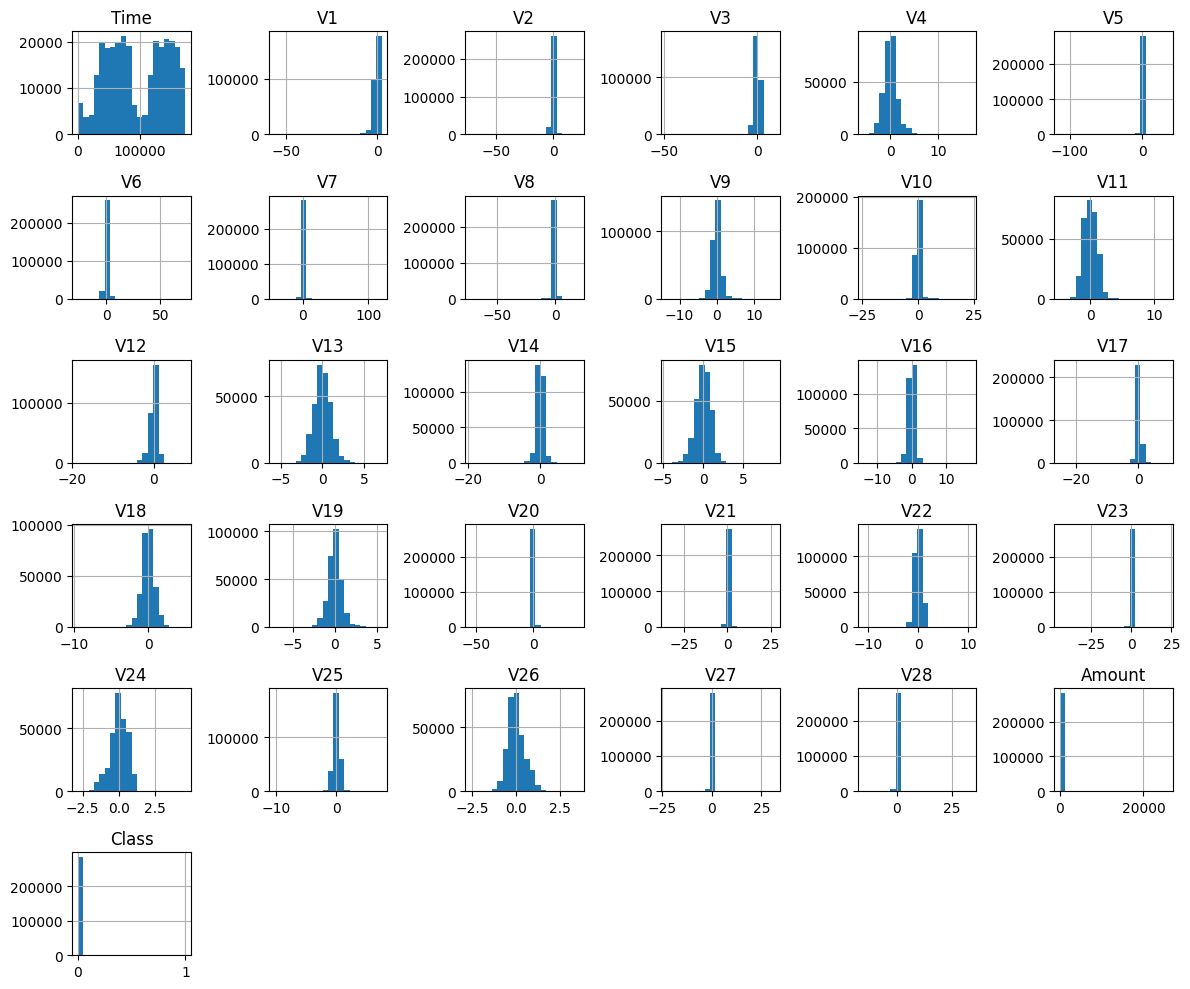

In [7]:
# Histogram of numeric features

numeric_features = df.select_dtypes(include=np.number).columns
df[numeric_features].hist(bins=20, figsize=(12, 10))
plt.tight_layout()
plt.show()

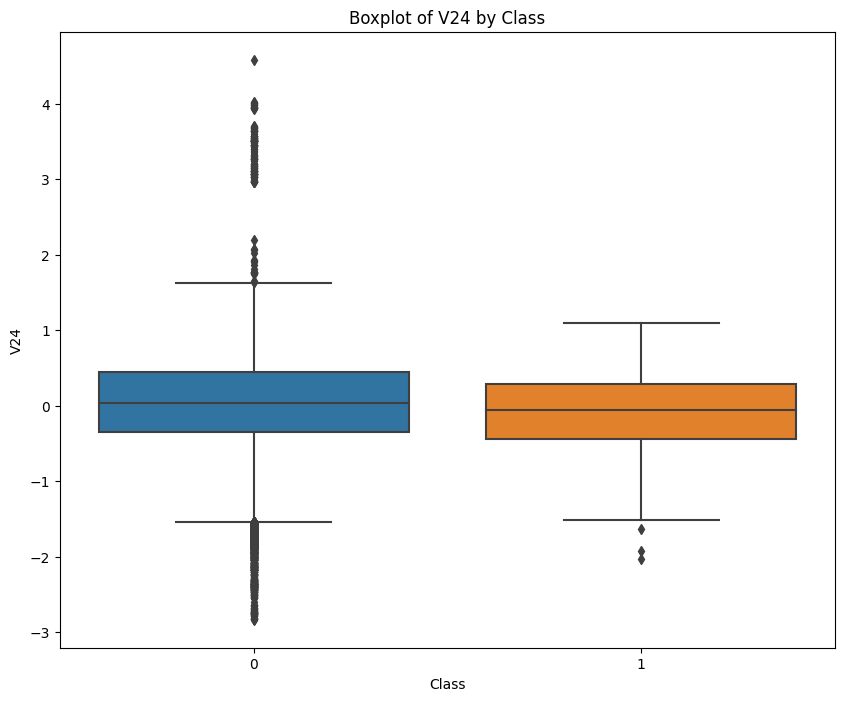

In [23]:
# Box plot of numeric features by Class

plt.figure(figsize=(10, 8))
sns.boxplot(x=df['Class'], y=df['V24'])
plt.title("Boxplot of V24 by Class")
plt.xlabel("Class")
plt.ylabel("V24")
plt.show()

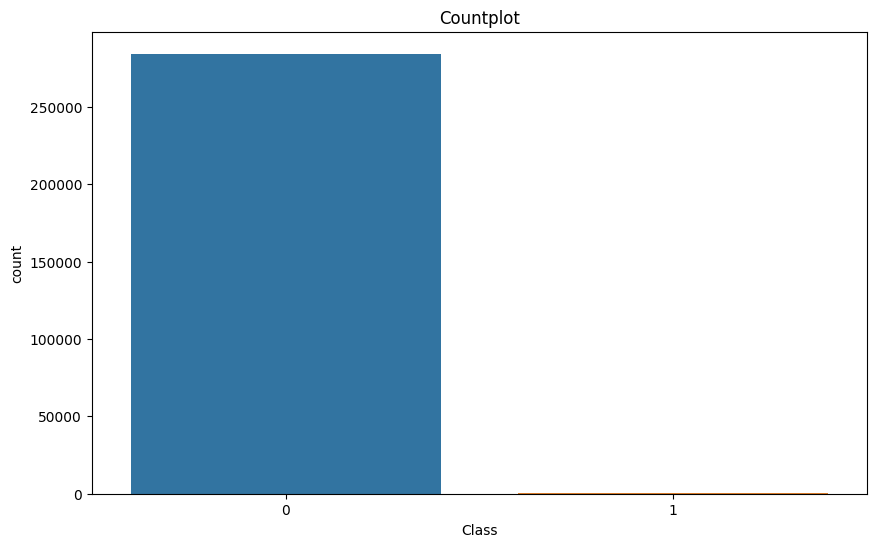

In [16]:
# Countplot

plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=df)
plt.title('Countplot')
plt.show()

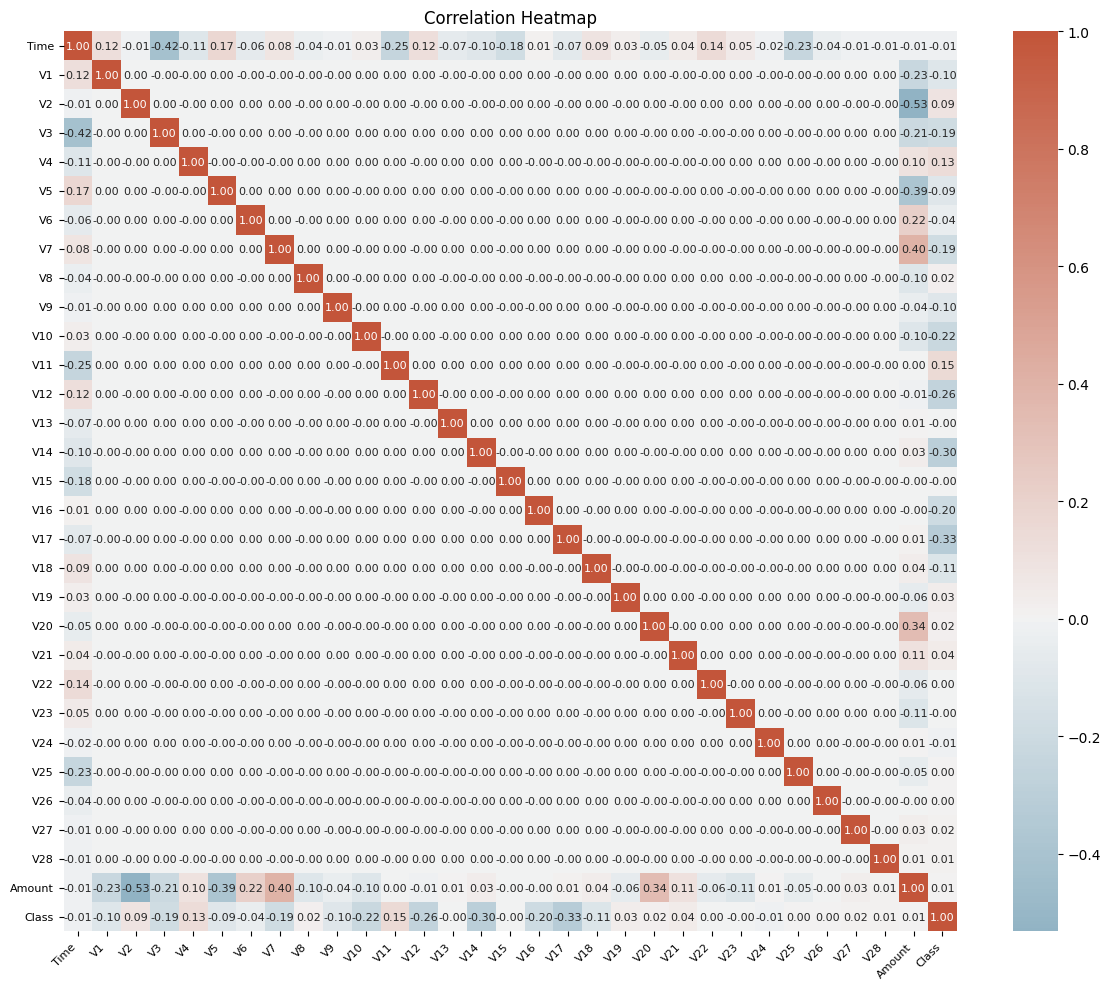

In [10]:
# Heatmap

plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, center=0, annot_kws={"size": 8})
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Advanced Analysis

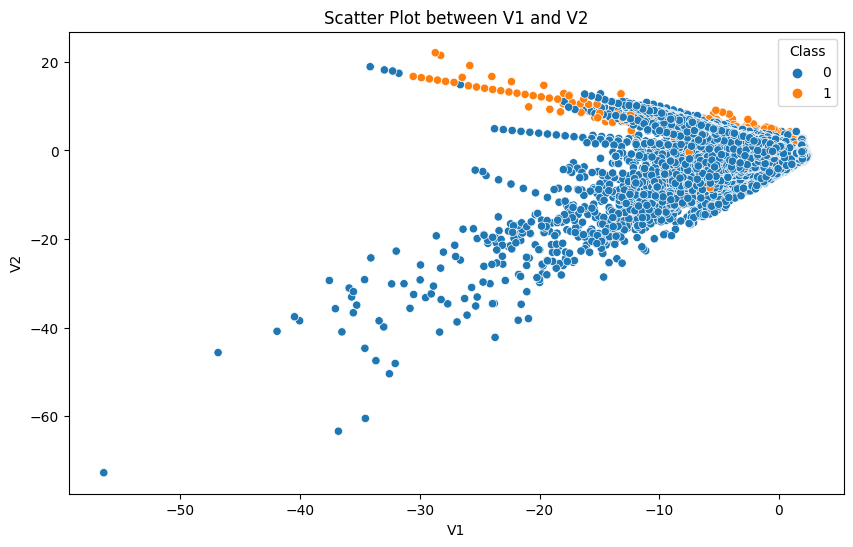

In [13]:
# Scatter plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x='V1', y='V2', hue='Class', data=df)
plt.title('Scatter Plot between V1 and V2')
plt.show()

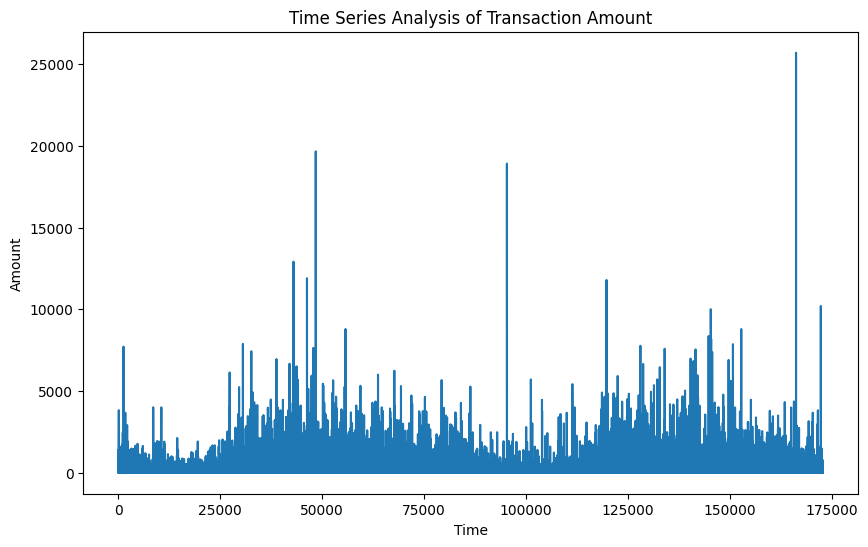

In [12]:
# Time series analysis - Line Plot

plt.figure(figsize=(10, 6))
plt.plot(df['Time'], df['Amount'])
plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Time Series Analysis of Transaction Amount')
plt.show()

In [14]:
# Outlier detection using IQR

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print("Outliers:")
print(outliers)

Outliers:
            Time        V1        V2        V3        V4        V5        V6  \
2            1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
20          16.0  0.694885 -1.361819  1.029221  0.834159 -1.191209  1.309109   
51          36.0 -1.004929 -0.985978 -0.038039  3.710061 -6.631951  5.122103   
64          42.0 -0.522666  1.009923  0.276470  1.475289 -0.707013  0.355243   
85          55.0 -4.575093 -4.429184  3.402585  0.903915  3.002224 -0.491078   
...          ...       ...       ...       ...       ...       ...       ...   
284735  172727.0 -1.661169 -0.565425  0.294268 -1.549156 -2.301359  2.365956   
284748  172738.0  1.634178 -0.486939 -1.975967  0.495364  0.263635 -0.713049   
284753  172743.0  1.465737 -0.618047 -2.851391  1.425282  0.893893 -0.958325   
284757  172745.0 -1.757643 -0.982659  1.091540 -1.409539 -0.662159  0.046930   
284806  172792.0 -0.533413 -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8   

In [15]:
# Save the updated dataset

df.to_csv('creditcard_processed.csv', index=False)